# Explorative Analysis
I am using this notebook to explore the dataset of the Rust QSim and define some initial analysis figures.

In [2]:
%load_ext autoreload
%autoreload 2

import sys

print(sys.executable)
print(sys.path[:5])

# Importing necessary libraries
# import seaborn as sns

from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd

from scripts.load_utils import discover, read_aggregated_routing, read_aggregated_qsim

/opt/homebrew/anaconda3/envs/router/bin/python
['/Users/paulh/Library/Application Support/JetBrains/IntelliJIdea2025.3/plugins/python-ce/helpers/jupyter_debug', '/Users/paulh/Library/Application Support/JetBrains/IntelliJIdea2025.3/plugins/python-ce/helpers/pydev', '/Users/paulh/git/parallel-qsim-berlin', '/Users/paulh/git/parallel-qsim-berlin/src/main/java', '/Users/paulh/git/parallel-qsim-berlin/src/test/java']


## Load QSim Instrument Data

Now, let's discover the runs in the output directory and load them.

In [3]:
root = Path("/Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct")
root_10pct = Path("/Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/10pct")
runs = discover(root)
runs.extend(discover(root_10pct))
print(runs)

[RunMeta(run_id='sim1_hor0_w4_r1_1pct', sim_thread_count=1, horizon=0, worker=4, routing_threads=1, pct=1, sim_path=PosixPath('/Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim1_hor0_w4_r1_1pct_sim'), server_paths=(ServerPath(server_number=0, path=PosixPath('/Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim1_hor0_w4_r1_1pct_server0')),)), RunMeta(run_id='sim1_hor0_w4_r24_1pct', sim_thread_count=1, horizon=0, worker=4, routing_threads=24, pct=1, sim_path=PosixPath('/Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim1_hor0_w4_r24_1pct_sim'), server_paths=(ServerPath(server_number=0, path=PosixPath('/Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim1_hor0_w4_r24_1pct_server0')),)), RunMeta(run_id='sim1_hor600_w4_r24_1pct', sim_thread_count=1, horizon=600, worker=4, routing_threads=24, pct=1, sim_path=PosixPath('/Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim1_hor600_w4_r24_1pct_sim'), server

In [4]:
qsim_data = {}
example_run_id = "sim8_hor600_w4_r24_1pct"
for run in runs:
    # if run.run_id != example_run_id:
    #     continue
    if run.worker != 4:
        continue

    if run.sim_thread_count != 8 and run.sim_thread_count != 64 and run.sim_thread_count != 192:
        continue

    if run.pct == 1:
        if run.routing_threads != 1 and run.routing_threads != 192:
            continue
        # else:
        #     if run.horizon == 0 and run.routing_threads != 192:
        #         continue
    if run.pct == 10:
        if run.routing_threads != 24 and run.routing_threads != 288:
            continue
        # else:
        #     if run.horizon == 0 and run.routing_threads != 288:
        #         continue

    print(f"Loading run {run.run_id}")
    qsim = read_aggregated_qsim(run)
    qsim = qsim[qsim["func_name"] == "run"]
    qsim_data[run.run_id] = qsim

Loading run sim8_hor0_w4_r1_1pct
Reading parquet:  /Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim8_hor0_w4_r1_1pct_sim/instrument/instrument_aggregated.parquet
Loading run sim8_hor0_w4_r192_1pct
Reading parquet:  /Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim8_hor0_w4_r192_1pct_sim/instrument/instrument_aggregated.parquet
Loading run sim8_hor200_w4_r1_1pct
Reading parquet:  /Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim8_hor200_w4_r1_1pct_sim/instrument/instrument_aggregated.parquet
Loading run sim8_hor200_w4_r192_1pct
Reading parquet:  /Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim8_hor200_w4_r192_1pct_sim/instrument/instrument_aggregated.parquet
Loading run sim8_hor600_w4_r1_1pct
Reading parquet:  /Users/paulh/runs-svn/rust-qsim/async-routing-2026/profiling/1pct/sim8_hor600_w4_r1_1pct_sim/instrument/instrument_aggregated.parquet
Loading run sim8_hor600_w4_r192_1pct
Reading parquet:  /Users/pau

Extract some example run data from a dataset to validate the loading process.

In [5]:
# use data from run "sim8_hor600_w4_r192_1pct". Filter for func_name=run
# example_data = qsim_data[example_run_id]
# example_data_run = example_data[example_data["func_name"] == "run"]
# print(example_data_run.head())
#
# del example_data, example_data_run

Prepare data for the main plot: RTR vs. Number of CPUs by Percentage

In [6]:
# for all data, filter for func_name="run", group by run_id, take mean from duration_min_ns and add as "duration_ns" column, remain with sim_cpus, horizon, worker_threads, router_threads, pct
all_runs_data = pd.concat(qsim_data.values())
all_runs_data_run = all_runs_data[all_runs_data["func_name"] == "run"]
all_runs_grouped = all_runs_data_run.groupby("run_id").agg({"duration_min_ns": "mean"}).reset_index()
all_runs_grouped = all_runs_grouped.merge(
    all_runs_data_run[["run_id", "sim_thread_count", "horizon", "worker", "routing_threads", "pct"]].drop_duplicates(),
    on="run_id",
)
all_runs_grouped = all_runs_grouped.rename(columns={"duration_min_ns": "duration_ns"})

# Add a new column "rtr"
all_runs_grouped["rtr"] = (60 * 60 * 36 * 1e9) / all_runs_grouped["duration_ns"]

print(all_runs_grouped.head())

                        run_id   duration_ns  sim_thread_count  horizon  \
0     sim192_hor0_w4_r192_1pct  1.719470e+11               192        0   
1       sim192_hor0_w4_r1_1pct  2.155972e+11               192        0   
2     sim192_hor0_w4_r24_10pct  5.340843e+11               192        0   
3    sim192_hor0_w4_r288_10pct  5.605842e+11               192        0   
4  sim192_hor1800_w4_r192_1pct  1.064795e+10               192     1800   

   worker  routing_threads  pct           rtr  
0       4              192    1    753.720536  
1       4                1    1    601.120965  
2       4               24   10    242.658343  
3       4              288   10    231.187402  
4       4              192    1  12171.361884  


In [7]:
# print all_runs_grouped as latex table
# use columns: "sim_thread_count" as "partitions", "horizon" as it is, "routing_threads" to "routing threads", "worker" as it is, "pct" to "sample (%)", "rtr" to "RTR".
# sort by sim_thread_count (asc), horizon (asc), routing_threads (asc), worker (asc), pct (asc)
latex_table = all_runs_grouped[
    ["sim_thread_count", "pct", "horizon", "routing_threads", "rtr"]
].copy()

latex_table = (latex_table.sort_values(
    by=["sim_thread_count", "pct", "horizon", "routing_threads"]
).reset_index(drop=True))

latex_table.insert(0, "index", range(1, len(latex_table) + 1))
latex = latex_table.to_latex(index=False, float_format="%.0f", escape=False, column_format="c|cccc|c",
                             header=["run id", "partitions", "sample (\\%)", "horizon", "routing threads", "RTR"])

lines = latex.splitlines()

new_lines = []
in_body = False
prev_partition = None
prev_sample = None

for line in lines:
    stripped = line.strip()

    if stripped == r"\midrule":
        in_body = True
        new_lines.append(line)
        continue

    if stripped == r"\bottomrule":
        in_body = False
        new_lines.append(line)
        continue

    if in_body and stripped.endswith(r"\\"):
        parts = [p.strip() for p in stripped[:-2].split("&")]
        current_partition = parts[1]  # partitions
        current_sample = parts[2]  # sample (%)

        if prev_partition is not None:
            if current_partition != prev_partition:
                new_lines.append(r"\midrule")
            elif current_sample != prev_sample:
                new_lines.append(r"\hdashline")

        new_lines.append(line)
        prev_partition = current_partition
        prev_sample = current_sample
    else:
        new_lines.append(line)

latex = "\n".join(new_lines)
latex = latex.replace("sample (%)", r"sample (\%)")

print(latex)


\begin{tabular}{c|cccc|c}
\toprule
run id & partitions & sample (\%) & horizon & routing threads & RTR \\
\midrule
1 & 8 & 1 & 0 & 1 & 552 \\
2 & 8 & 1 & 0 & 192 & 521 \\
3 & 8 & 1 & 200 & 1 & 623 \\
4 & 8 & 1 & 200 & 192 & 8535 \\
5 & 8 & 1 & 600 & 1 & 640 \\
6 & 8 & 1 & 600 & 192 & 9879 \\
7 & 8 & 1 & 1800 & 1 & 620 \\
8 & 8 & 1 & 1800 & 192 & 8474 \\
\hdashline
9 & 8 & 10 & 0 & 24 & 128 \\
10 & 8 & 10 & 0 & 288 & 136 \\
11 & 8 & 10 & 200 & 24 & 1136 \\
12 & 8 & 10 & 200 & 288 & 1260 \\
13 & 8 & 10 & 600 & 24 & 983 \\
14 & 8 & 10 & 600 & 288 & 1058 \\
15 & 8 & 10 & 1800 & 24 & 712 \\
16 & 8 & 10 & 1800 & 288 & 770 \\
\midrule
17 & 64 & 1 & 0 & 1 & 592 \\
18 & 64 & 1 & 0 & 192 & 657 \\
19 & 64 & 1 & 200 & 1 & 626 \\
20 & 64 & 1 & 200 & 192 & 8766 \\
21 & 64 & 1 & 600 & 1 & 621 \\
22 & 64 & 1 & 600 & 192 & 12801 \\
23 & 64 & 1 & 1800 & 1 & 623 \\
24 & 64 & 1 & 1800 & 192 & 14091 \\
\hdashline
25 & 64 & 10 & 0 & 24 & 198 \\
26 & 64 & 10 & 0 & 288 & 188 \\
27 & 64 & 10 & 200 & 24 & 1261 

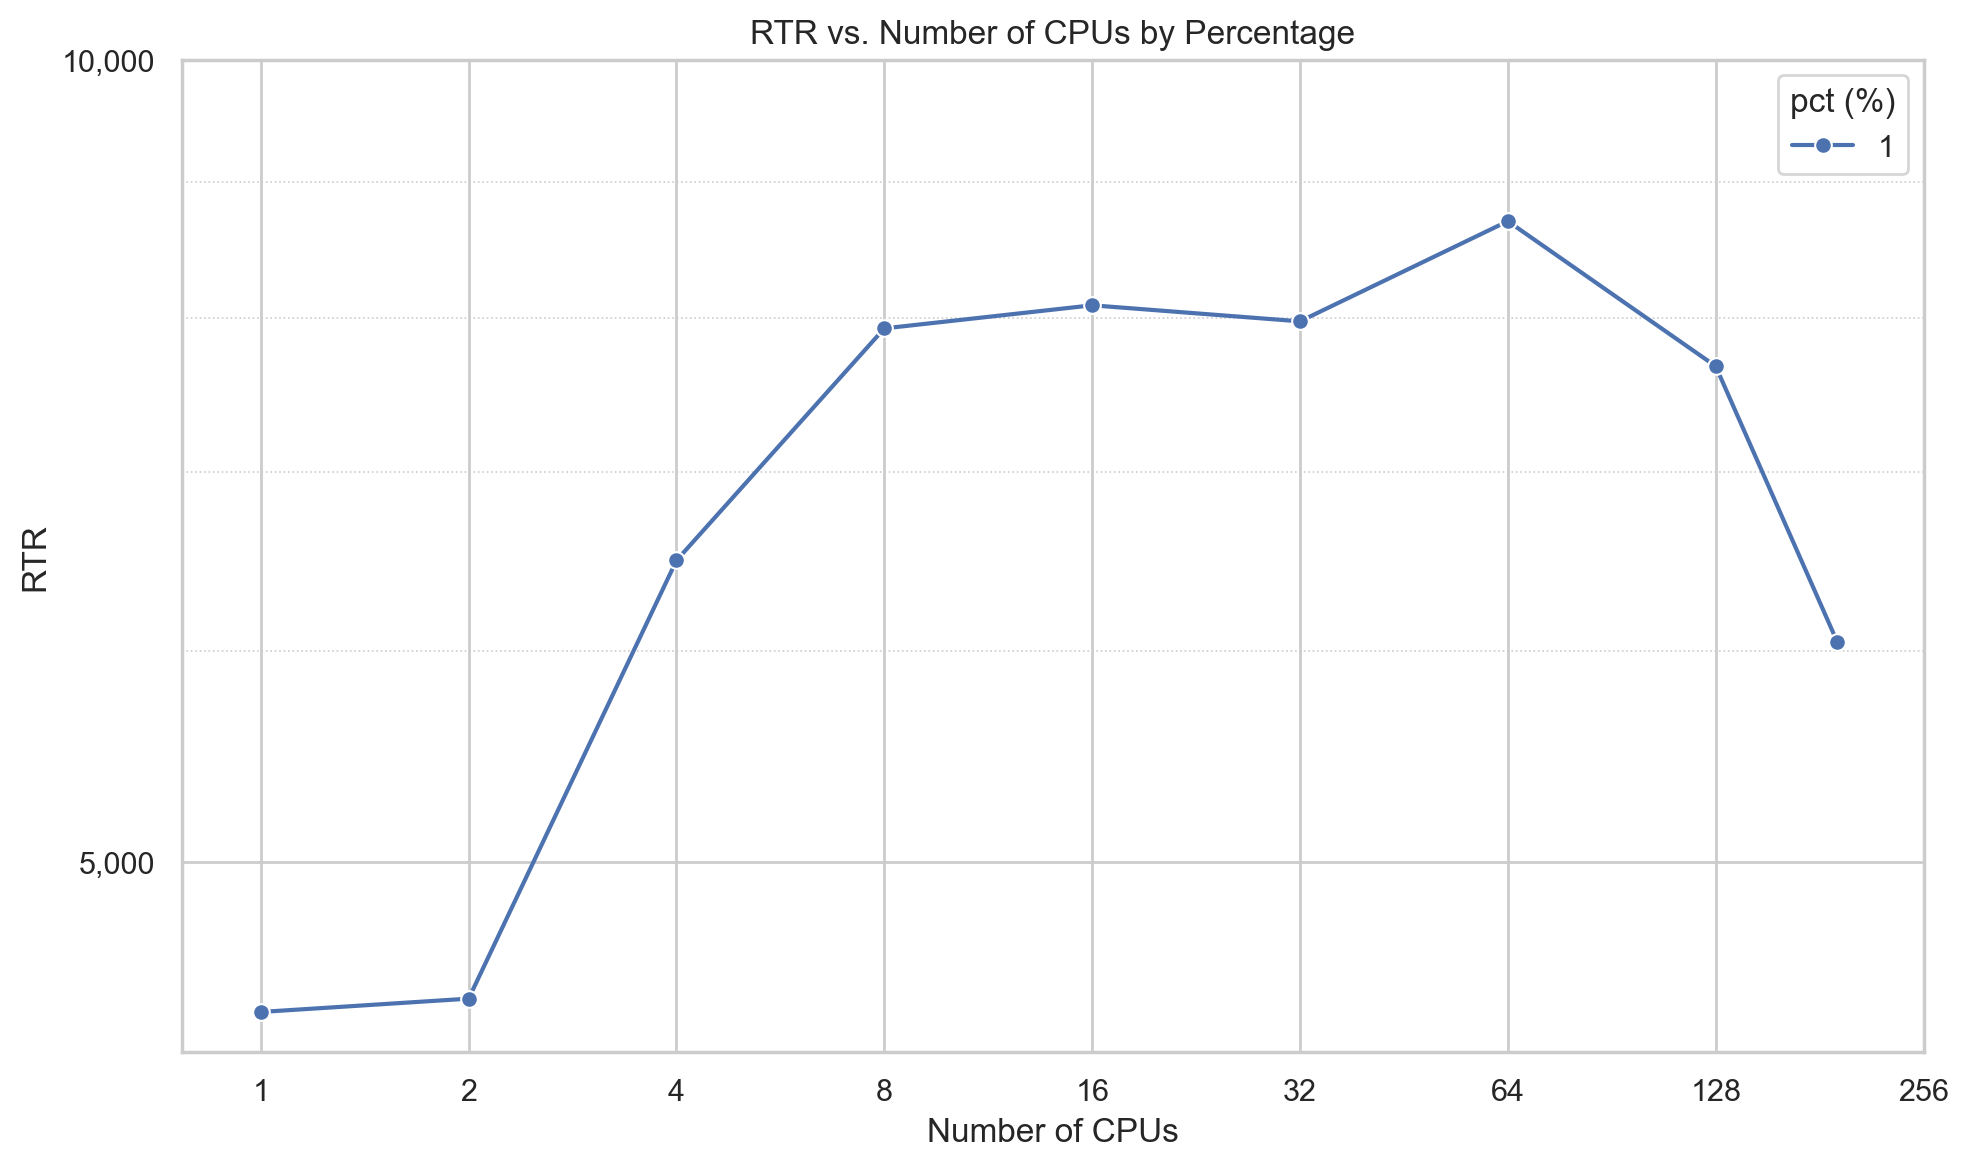

In [24]:
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter, FixedLocator, FuncFormatter

filtered = all_runs_grouped[
    (all_runs_grouped["horizon"] == 600) &
    (all_runs_grouped["worker"] == 4) &
    (all_runs_grouped["routing_threads"] == 24)  # change to 192 if needed
    ]

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=filtered,
    x="sim_thread_count",
    y="rtr",
    hue="pct",
    marker="o"
)

ax.set_title("RTR vs. Number of CPUs by Percentage")
ax.set_xlabel("Number of CPUs")
ax.set_ylabel("RTR")

ax.set_yscale("log", base=10)
ax.set_xscale("log", base=2)

# Clean x ticks: show actual CPU counts
xvals = [1, 2, 4, 8, 16, 32, 64, 128, 256]
ax.set_xticks(xvals)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(plt.NullFormatter())

yticks = [1000, 5000, 10000]
ax.yaxis.set_major_locator(FixedLocator(yticks))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
ax.yaxis.set_minor_formatter(plt.NullFormatter())

ax.grid(True, which="major", linewidth=1.0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.6)

ax.set_ylim(top=10_000)
ax.legend(title="pct (%)")

plt.tight_layout()
plt.show()

Now, let's plot the stacked bar chart for phases.

# Untested from below.

In [ ]:
# print all unique func_names
print(all_runs_data["func_name"].unique())

# filter all runs data for func_name in ['move_links','move_nodes','notify_end_all', 'notify_wakeup_all']
# phases_of_interest = ['move_links', 'move_nodes', 'notify_end_all', 'notify_wakeup_all']
# phases_data = all_runs_data[all_runs_data["func_name"].isin(phases_of_interest)]
#
# # group by run_id and func_name. take mean of duration_mean_ns. Stick with horizon, worker_threads, router_threads, pct
# phases_grouped = phases_data.groupby(["run_id", "func_name"]).agg({"duration_mean_ns": "mean"}).reset_index()
# phases_grouped = phases_grouped.merge(
#     phases_data[["run_id", "sim_cpus", "horizon", "worker_threads", "router_threads", "pct"]].drop_duplicates(),
#     on="run_id",
# )
# print(phases_grouped.head())
#
# del phases_data

In [ ]:
do_step_data = all_runs_data[all_runs_data["func_name"] == "do_step"]

do_step_grouped = do_step_data.groupby(["run_id", "func_name"]).agg({"duration_mean_ns": "mean"}).reset_index()
do_step_grouped = do_step_grouped.merge(
    phases_data[["run_id", "sim_cpus", "horizon", "worker_threads", "router_threads", "pct"]].drop_duplicates(),
    on="run_id",
)

del do_step_data

In [ ]:
# plot bar chart. filter for func_name="do_step" with sim_cpus on x axis, duration_mean_ns on y axis
plt.figure(figsize=(10, 6))
sns.barplot(
    data=do_step_grouped,
    x="sim_cpus",
    y="duration_mean_ns",
    hue="pct"
)
plt.title("do_step Duration by Number of CPUs and Percentage")
plt.xlabel("Number of CPUs")
plt.ylabel("Duration Mean (ns)")
plt.legend(title="pct (%)")
plt.tight_layout()
plt.show()

In [ ]:
# plot stacked bar chart with sim_cpus on x axis, duration_mean_ns on y axis, hue func_name and stack, facet by pct
import numpy as np
import matplotlib.pyplot as plt

for pct in sorted(phases_grouped["pct"].unique()):

    data = phases_grouped[phases_grouped["pct"] == pct]

    pivot = (
        data.pivot(
            index="sim_cpus",
            columns="func_name",
            values="duration_mean_ns"
        )
        .sort_index()
    )

    # Treat x as categorical
    x_labels = pivot.index.astype(str)
    x_pos = np.arange(len(pivot))

    plt.figure(figsize=(12, 6))

    bottom = np.zeros(len(pivot))

    for func in pivot.columns:
        plt.bar(
            x_pos,
            pivot[func].values,
            bottom=bottom,
            label=func,
            width=0.7
        )
        bottom += pivot[func].values

    plt.title(f"Phase Durations by Number of CPUs ({pct}% sample)")
    plt.xlabel("Number of CPUs")
    plt.ylabel("Duration Mean (ns)")

    # Categorical x-axis
    plt.xticks(x_pos, x_labels)

    plt.legend(title="Phase")
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for pct in sorted(phases_grouped["pct"].unique()):

    data = phases_grouped[phases_grouped["pct"] == pct]

    pivot = (
        data.pivot(
            index="sim_cpus",
            columns="func_name",
            values="duration_mean_ns"
        )
        .sort_index()
    )

    # Normalize each row so the stacked bar sums to 1.0
    row_sums = pivot.sum(axis=1)
    pivot_rel = pivot.div(row_sums, axis=0).fillna(0.0)

    # Treat x as categorical
    x_labels = pivot_rel.index.astype(str)
    x_pos = np.arange(len(pivot_rel))

    plt.figure(figsize=(12, 6))

    bottom = np.zeros(len(pivot_rel))

    for func in pivot_rel.columns:
        vals = pivot_rel[func].values
        plt.bar(
            x_pos,
            vals,
            bottom=bottom,
            label=func,
            width=0.7
        )
        bottom += vals

    plt.title(f"Relative Phase Durations by Number of CPUs ({pct}% sample)")
    plt.xlabel("Number of CPUs")
    plt.ylabel("Relative duration (fraction of total)")

    plt.xticks(x_pos, x_labels)
    plt.ylim(0, 1)  # because proportions

    plt.legend(title="Phase")
    plt.tight_layout()
    plt.show()

## Loading Routing Data

In [ ]:
routing_data: dict[str, pd.DataFrame] = {}

for run in runs:
    print(f"Loading routing data for run {run.run_id}")
    routing_data[run.run_id] = read_aggregated_routing(run)


In [ ]:
ex_id = "sim4_hor600_w4_r192_10pct"

# group by rank and count number of occurrences of each rank
routing_example = routing_data[ex_id]

print(routing_example.head())
routing_example_grouped = routing_example.groupby("rank").size().reset_index(name="count")
print(routing_example_grouped.head())

del routing_example, routing_example_grouped

In [ ]:
all_routing_data = pd.concat(routing_data.values())

#filter out all replace_route entries where request_uuid_u128=0
all_routing_data = all_routing_data[
    ~((all_routing_data["func_name"] == "replace_route") & (all_routing_data["request_uuid_u128"] == 0))]

print(all_routing_data.head())

In [ ]:
# filter all_routing_data for pct=10 and func_name="replace_route". group by run_id and process_id, preserve sim_cpus,horizon,worker_threads,router_threads,pct. Sum duration_ns.
routing_filtered = all_routing_data[all_routing_data["func_name"] == "replace_route"]
routing_grouped = routing_filtered.groupby(["run_id", "process_id"]).agg({"duration_ns": "sum"}).reset_index()
routing_grouped = routing_grouped.merge(
    routing_filtered[["run_id", "sim_cpus", "horizon", "worker_threads", "router_threads", "pct"]].drop_duplicates(),
    on="run_id",
)
print(routing_grouped.head())

# join all_runs_data_run and routing_grouped on run_id and process_id to get total duration_ns
merged_routing = routing_grouped.merge(
    all_runs_data_run[["run_id", "process_id", "duration_min_ns"]],
    on=["run_id", "process_id"],
    suffixes=("_routing", "_total")
)
print(merged_routing.head())

del routing_filtered, routing_grouped

For each run, choose the process that needed to wait the longest for routing and plot that against the total duration_ns of that process.

In [ ]:
# plot bar chart. filter for pct=10. group by run_id, take max of duration_ns and duration_min_ns of the corresponding entry. Plot sim_cpus on x axis, duration_ns and duration_min_ns on y axis next to each other as bars. use seaborn
idx = merged_routing.groupby("run_id")["duration_ns"].idxmax()
max_routing_recv = merged_routing.loc[idx].reset_index(drop=True)
print(max_routing_recv.head())

for p in sorted(max_routing_recv["pct"].unique()):
    pct_ = max_routing_recv[max_routing_recv["pct"] == p]

    plt.figure(figsize=(10, 6))
    sns.pointplot(data=pct_,
                  x="sim_cpus",
                  y="duration_ns",
                  color="blue",
                  label="Cumulative Waiting for Routing (ns)",
                  marker="o")
    sns.pointplot(data=pct_,
                  x="sim_cpus",
                  y="duration_min_ns",
                  color="orange",
                  label="Total Duration (ns)",
                  marker="o")

    plt.title(f"Cumulative Waiting for Routing vs. Total Duration by Number of CPUs ({p}% sample)")
    plt.xlabel("Number of CPUs")
    plt.ylabel("Duration (ns)")
    plt.legend()
    plt.tight_layout()
    plt.show()